In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Overview of the Data

The dataset contains transaction-level records from the Xente eCommerce platform and consists of **95,662 transactions** and **16 features**.

The features include customer identifiers, transaction details, product information, channel information, pricing strategy, and a fraud indicator.

### Data Types

The dataset contains:

- **String (object) features:** TransactionId, BatchId, AccountId, SubscriptionId, CustomerId, CurrencyCode, ProviderId, ProductId, ProductCategory, ChannelId, and TransactionStartTime.
- **Numerical features:** CountryCode, Amount, Value, PricingStrategy, and FraudResult.

### Initial Observations

- No missing values were detected in any column.
- CountryCode contains only a single value (256), indicating no variability.
- Fraudulent transactions are very rare, suggesting a highly imbalanced target variable.
- Several identifier columns contain a large number of unique values and may require special handling during feature engineering.

In [4]:
df = pd.read_csv("../data/data.csv")

df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [5]:
df.shape

(95662, 16)

In [7]:
df.columns

Index(['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
       'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId',
       'ProductCategory', 'ChannelId', 'Amount', 'Value',
       'TransactionStartTime', 'PricingStrategy', 'FraudResult'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

Summary Statistics

# Summary Statistics

Descriptive statistics were calculated to understand the central tendency and spread of numerical variables.

### Key Findings

- The average transaction amount is approximately **6,718**, while the median is only **1,000**, indicating a highly skewed distribution.
- Transaction amounts range from **-1,000,000** to **9,880,000**, showing substantial variability.
- The large difference between the mean and median confirms the presence of extreme values.
- Fraudulent transactions account for only **0.2%** of the dataset (mean FraudResult ≈ 0.002), highlighting a severe class imbalance.
- CountryCode has no variation (all values equal 256) and is unlikely to contribute useful predictive information.

In [9]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [10]:
df.describe(include="object")

C:\Users\dania\AppData\Local\Temp\ipykernel_5028\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


Missing Value

# Identifying Missing Values

Missing value analysis was performed across all features.

### Key Findings

- No missing values were detected in the dataset.
- All 95,662 records contain complete information across all 16 features.

### Implications

Since the dataset is complete, no imputation strategies are required at this stage. This simplifies the preprocessing workflow and allows feature engineering efforts to focus on behavioral and transactional patterns.

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Series([], dtype: int64)

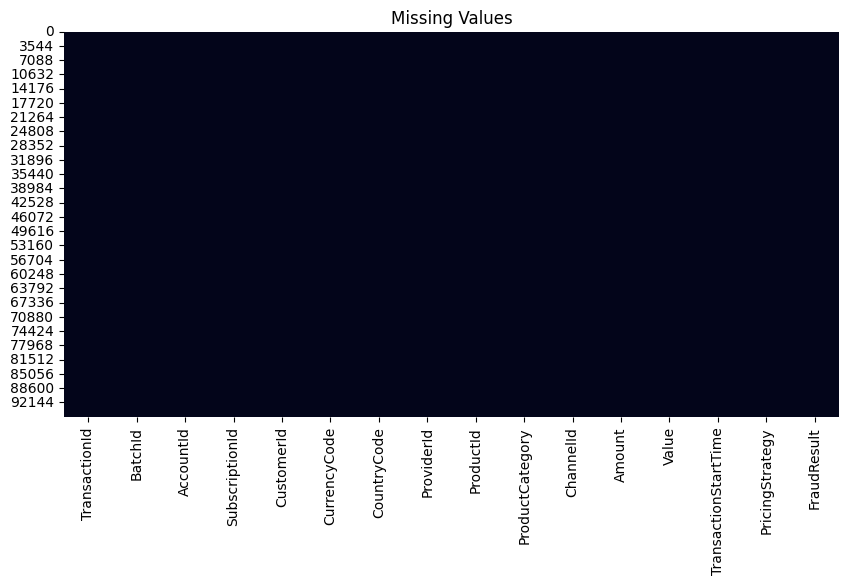

In [12]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

Numerical Feature Distributions

# Distribution of Numerical Features

Histograms were used to examine the distributions of numerical variables.

### Key Findings

- The Amount feature exhibits a strong right-skewed distribution.
- Most transactions are concentrated around relatively small values.
- A small number of transactions have exceptionally large amounts, creating a long right tail.
- Negative transaction amounts are also present, indicating refunds, reversals, or credit transactions.
- The sharp concentration near zero suggests that low-value transactions dominate customer activity.

These observations suggest that scaling and transformation techniques may be beneficial during feature engineering.

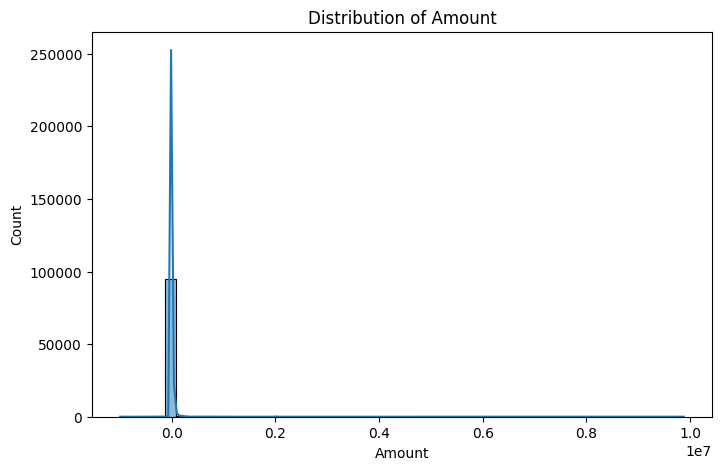

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Amount")
plt.show()

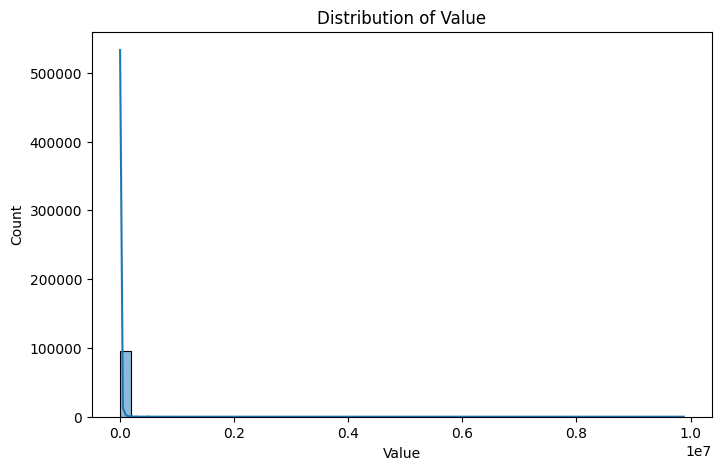

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Value"], bins=50, kde=True)
plt.title("Distribution of Value")
plt.show()

Categorical Features

# Distribution of Categorical Features

Categorical features were analyzed to understand customer transaction behavior across products and channels.

### Product Categories

The transaction volume is highly concentrated in a few categories:

- Financial Services: 45,405 transactions
- Airtime: 45,027 transactions
- Utility Bills: 1,920 transactions
- Data Bundles: 1,613 transactions

Most remaining categories contribute only a small proportion of transactions.

### Transaction Channels

Transaction activity is dominated by:

- ChannelId_3
- ChannelId_2

Other channels account for only a small percentage of total transactions.

### Key Findings

- Customer activity is concentrated within a small number of product categories.
- Financial Services and Airtime account for the vast majority of transactions.
- Transaction channels are highly imbalanced, with two channels handling most customer activity.
- Rare categories may require grouping or careful handling during feature engineering.

In [15]:
df["ProductCategory"].value_counts().head(10)

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

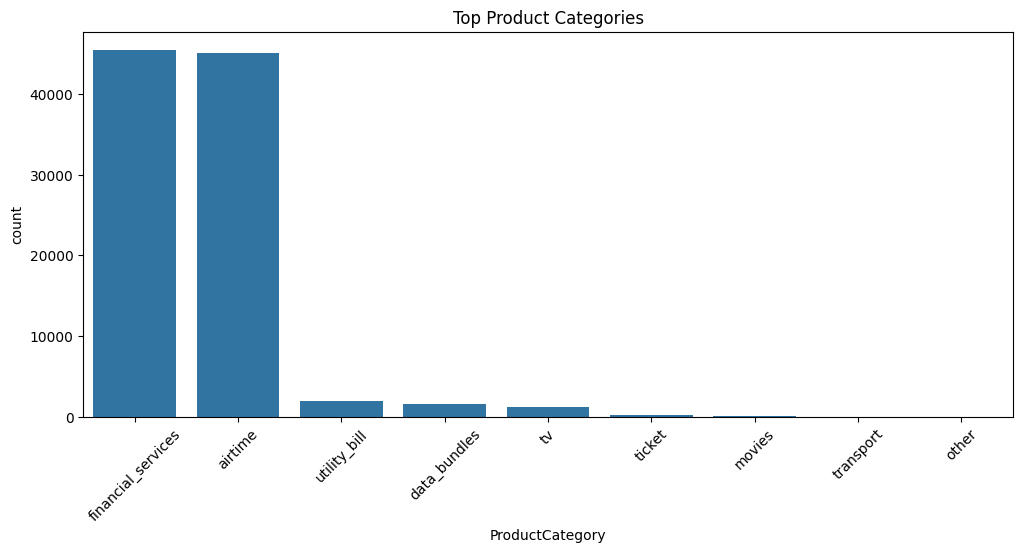

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(
    data=df,
    x="ProductCategory",
    order=df["ProductCategory"].value_counts().index[:10]
)

plt.xticks(rotation=45)
plt.title("Top Product Categories")
plt.show()

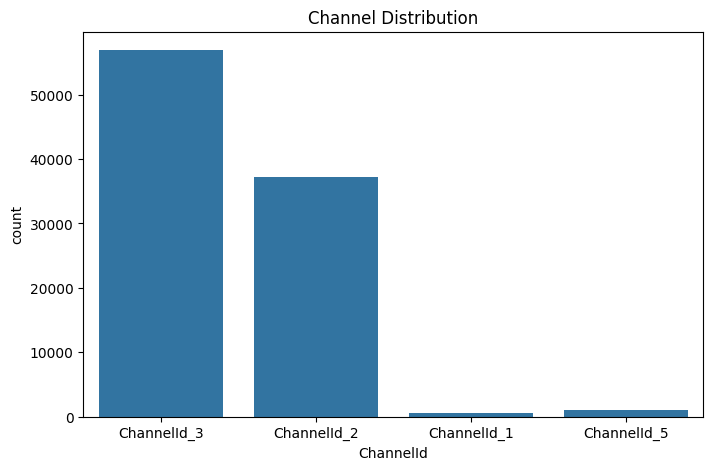

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ChannelId"
)

plt.title("Channel Distribution")
plt.show()

Correlation Analysis

# Correlation Analysis

A correlation matrix was generated to examine relationships among numerical variables.

### Key Findings

- Amount and Value have an extremely strong positive correlation (approximately 0.99).
- This indicates that both variables contain nearly identical information and may introduce multicollinearity if used together.
- Amount and Value both show moderate positive relationships with FraudResult, suggesting they may be useful predictors.
- PricingStrategy exhibits very weak correlations with other variables.
- CountryCode has zero variance and therefore provides no useful predictive information.

### Implications

The strong correlation between Amount and Value suggests that one of these variables may be removed during feature selection to reduce redundancy and simplify the model.

In [18]:
numeric_df = df.select_dtypes(include=np.number)

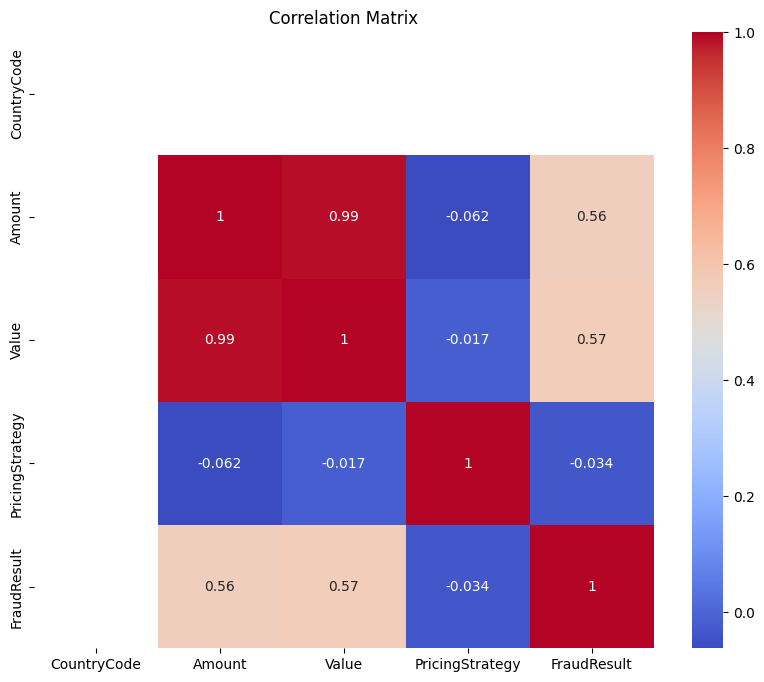

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Outliner Detection

# Outlier Detection

Boxplots were used to identify extreme observations in transaction-related variables.

### Key Findings

- A large number of extreme outliers are present in the Amount feature.
- Several transactions have values significantly larger than the majority of observations.
- The interquartile range appears compressed because the scale is dominated by a relatively small number of very large transactions.
- The distribution is strongly right-skewed, with a long upper tail.

### Implications

These outliers may represent important customer behavior rather than data errors. Therefore, they should be investigated carefully before considering removal. Techniques such as logarithmic transformation, robust scaling, or winsorization may be explored during feature engineering.

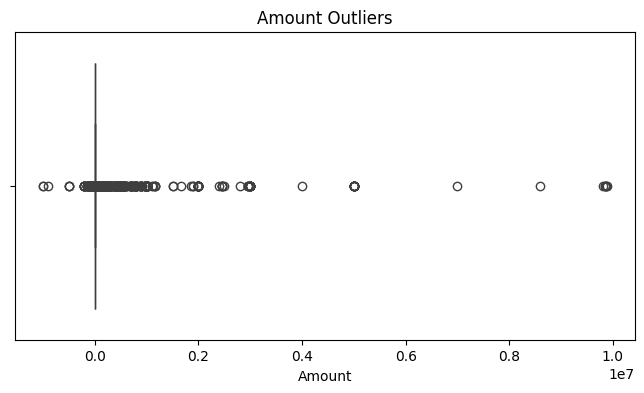

In [20]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Amount"])

plt.title("Amount Outliers")
plt.show()

Transaction Time Analysis

In [21]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [22]:
df["hour"] = df["TransactionStartTime"].dt.hour

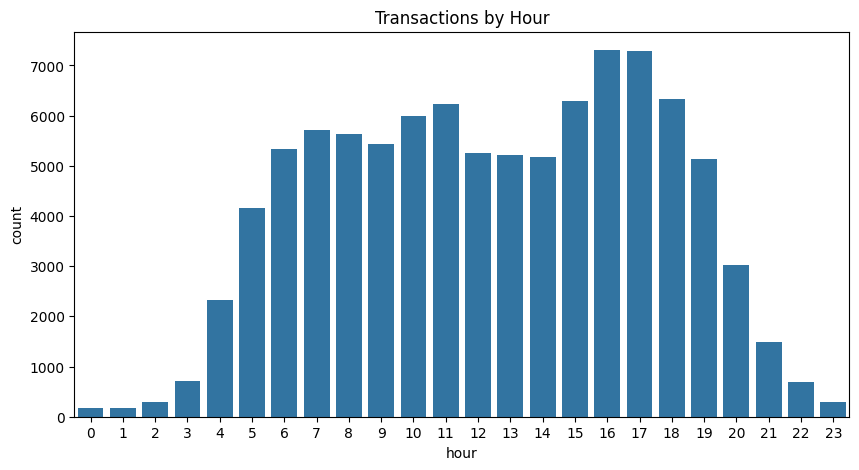

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="hour"
)

plt.title("Transactions by Hour")
plt.show()